In [1]:
pip install contractions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 6.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import contractions
# natural language toolkit
import nltk

# cuvinte comune (stopwords)
nltk.download('stopwords')
from nltk.corpus import stopwords

# impartirea documentului in cuvinte (tokenization)
nltk.download('punkt')
from nltk.tokenize import word_tokenize

# lemmatization (eliminarea pluralui / derivatelor cuvantului)
import spacy
nlp = spacy.load('en_core_web_sm')

# regex
import re

# DTM (document-term-matrix)
from sklearn.feature_extraction.text import CountVectorizer

# Impartirea setului de date in train & test
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score

from gensim.models import FastText, Word2Vec

import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


#Citirea datelor

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
path = '/content/drive/MyDrive/Dataset/DISERTATIE.csv'


In [5]:
!pip install chardet

In [6]:
import os

path = '/content/gdrive/MyDrive/Dataset/DISERTATIE.csv'
print("Files in the directory:")
print(os.listdir('/content/drive/MyDrive/Dataset'))

Files in the directory:


OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/Dataset'

In [7]:
import chardet

with open(path, 'rb') as file:
    rawdata = file.read()
    result = chardet.detect(rawdata)
    charenc = result['encoding']
    print(f"Detected encoding: {charenc}")

# Read the CSV file with the detected encoding
comments = pd.read_csv(path, encoding=charenc)
print(comments.head(5))

Detected encoding: Windows-1252
       label                                               text  \
0     israel  War is tragic, and this is no exception. That ...   
1     israel  While Israel waits for their loved ones being ...   
2  palestine  Well it definitely makes for a catchier headli...   
3  palestine  Hamas is not Palestine. Palestine is not Hamas...   
4  palestine  Why are none of the Pro-Palestine people mad a...   

           category                 createdAt          id  numberOfreplies  \
0  AskConservatives  2024-04-05T01:48:06.000Z  t1_ky3xra3                5   
1  AskConservatives  2024-04-05T15:49:09.000Z  t1_ky6qah7                1   
2  AskConservatives  2024-04-05T16:12:59.000Z  t1_ky6umjg                1   
3       Objectivism  2023-12-22T21:28:15.000Z  t1_keilnuw                1   
4       Objectivism  2023-12-22T21:55:08.000Z  t1_keiprnt                0   

       postId  upVotes              username  
0  t3_1bw5n83       28             Garfish16  
1 

In [ ]:
comments.head(5)

,label,text,category,createdAt,id,numberOfreplies,postId,upVotes,username
0,israel,"War is tragic, and this is no exception. That ...",AskConservatives,2024-04-05T01:48:06.000Z,t1_ky3xra3,5,t3_1bw5n83,28,Garfish16
1,israel,While Israel waits for their loved ones being ...,AskConservatives,2024-04-05T15:49:09.000Z,t1_ky6qah7,1,t3_1bw5n83,2,TheTiniestSound
2,palestine,Well it definitely makes for a catchier headli...,AskConservatives,2024-04-05T16:12:59.000Z,t1_ky6umjg,1,t3_1bw5n83,-1,Laniekea
3,palestine,Hamas is not Palestine. Palestine is not Hamas...,Objectivism,2023-12-22T21:28:15.000Z,t1_keilnuw,1,t3_18o3obf,5,Fit419
4,palestine,Why are none of the Pro-Palestine people mad a...,Objectivism,2023-12-22T21:55:08.000Z,t1_keiprnt,0,t3_18o3obf,1,BubblyNefariousness4


In [ ]:
comments.dtypes

label              object
text               object
category           object
createdAt          object
id                 object
numberOfreplies     int64
postId             object
upVotes             int64
username           object
dtype: object

In [ ]:
comments.shape

(400, 9)

In [ ]:
comments['label'].value_counts()

label
palestine    207
israel       193
Name: count, dtype: int64

In [8]:
category = {'israel': 1,
            'palestine': 0}
comments['labelnum'] = comments['label'].replace(category)
comments.head(5)


,label,text,category,createdAt,id,numberOfreplies,postId,upVotes,username,labelnum
0,israel,"War is tragic, and this is no exception. That ...",AskConservatives,2024-04-05T01:48:06.000Z,t1_ky3xra3,5,t3_1bw5n83,28,Garfish16,1
1,israel,While Israel waits for their loved ones being ...,AskConservatives,2024-04-05T15:49:09.000Z,t1_ky6qah7,1,t3_1bw5n83,2,TheTiniestSound,1
2,palestine,Well it definitely makes for a catchier headli...,AskConservatives,2024-04-05T16:12:59.000Z,t1_ky6umjg,1,t3_1bw5n83,-1,Laniekea,0
3,palestine,Hamas is not Palestine. Palestine is not Hamas...,Objectivism,2023-12-22T21:28:15.000Z,t1_keilnuw,1,t3_18o3obf,5,Fit419,0
4,palestine,Why are none of the Pro-Palestine people mad a...,Objectivism,2023-12-22T21:55:08.000Z,t1_keiprnt,0,t3_18o3obf,1,BubblyNefariousness4,0


In [ ]:
comments.dtypes

label              object
text               object
category           object
createdAt          object
id                 object
numberOfreplies     int64
postId             object
upVotes             int64
username           object
labelnum            int64
dtype: object

In [9]:
print('Nr. de opinii israel', len(comments[comments['labelnum']==1]))
print('Nr. de opinii palestina', len(comments[comments['labelnum']==0]))

Nr. de opinii israel 193
Nr. de opinii palestina 207


#Procesarea textului

In [10]:
def preprocesare_text(document):
    # Convertim textul in text scris cu litera mica
    document = document.lower()
    # Inlocuim formele scurte (contractions)
    document = contractions.fix(document)
    # Regex
    # ^ = NOT
    document = re.sub(r'[^\w\s]', ' ', document)
    document = re.sub(r'[^a-z ]', '', document)
    # Impartim documentul in cuvinte (tokenization)
    document = word_tokenize(document)
    # Inlaturam cuvintele comune (stopwords)
    cuv_comune = stopwords.words('english')
    document = [element for element in document if element not in cuv_comune]
    # Convertim din lista de cuvinte in string
    document = " ".join(document)
    # Reducem cuvantul la lema sa (Lemmatization)
    document = " ".join([word.lemma_ for word in nlp(document)])

    return document

In [ ]:
comments.head(2)

,label,text,category,createdAt,id,numberOfreplies,postId,upVotes,username,labelnum
0,israel,"War is tragic, and this is no exception. That ...",AskConservatives,2024-04-05T01:48:06.000Z,t1_ky3xra3,5,t3_1bw5n83,28,Garfish16,1
1,israel,While Israel waits for their loved ones being ...,AskConservatives,2024-04-05T15:49:09.000Z,t1_ky6qah7,1,t3_1bw5n83,2,TheTiniestSound,1


In [11]:
comments['text_prep'] = comments['text'].apply(preprocesare_text)

In [ ]:
comments.head(2)

,label,text,category,createdAt,id,numberOfreplies,postId,upVotes,username,labelnum,text_prep
0,israel,"War is tragic, and this is no exception. That ...",AskConservatives,2024-04-05T01:48:06.000Z,t1_ky3xra3,5,t3_1bw5n83,28,Garfish16,1,war tragic exception say would united states o...
1,israel,While Israel waits for their loved ones being ...,AskConservatives,2024-04-05T15:49:09.000Z,t1_ky6qah7,1,t3_1bw5n83,2,TheTiniestSound,1,israel wait love one hold hostage hamas rest w...


#DTM

In [12]:
comments.isnull().sum()

label              0
text               0
category           0
createdAt          0
id                 0
numberOfreplies    0
postId             0
upVotes            0
username           0
labelnum           0
text_prep          0
dtype: int64

In [13]:
# Construim un vocabular cu cele mai frecvente 6000 de cuvinte
vec = CountVectorizer(max_features=6000)

In [14]:
# Cream DTM-ul
dtm1 = vec.fit_transform(comments['text_prep'])

# Convertim in dataframe
dtm = pd.DataFrame(dtm1.toarray(),
                   columns=vec.get_feature_names_out())
dtm.head(5)

,abhor,abhorrent,ability,able,absolute,absolutely,absurd,abuse,accept,access,...,yes,yet,yield,yo,young,youth,zealot,zero,zionism,zionist
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Train Test Split

In [15]:
X_train_dtm, X_test_dtm, y_train_dtm, y_test_dtm = train_test_split(
    dtm,
    comments['labelnum'],
    train_size=0.8,
    random_state=42
)

In [16]:
print(len(X_train_dtm), len(X_test_dtm), len(y_train_dtm), len(y_test_dtm))

320 80 320 80


In [ ]:
y_test_dtm.mean()

0.4875

In [ ]:
y_train_dtm.mean()

0.48125

In [ ]:
X_train_dtm.head(2)

,abhor,abhorrent,ability,able,absolute,absolutely,absurd,abuse,accept,access,...,yes,yet,yield,yo,young,youth,zealot,zero,zionism,zionist
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#XGBoost Classifier

In [17]:
model = XGBClassifier(booster='gbtree',
                      objective='binary:logistic',
                      verbosity=3, #showing logs
                      learning_rate=0.1,
                      n_estimators=200,
                      max_depth=8,
                      max_leaves=32,
                      subsample=0.95,
                      eval_metric='auc'
                     )

In [18]:
model.fit(X_train_dtm, y_train_dtm, eval_set=[(X_test_dtm, y_test_dtm)])

[15:17:19] ======== Monitor (0): HostSketchContainer ========
[15:17:19] AllReduce: 0.004724s, 1 calls @ 4724us

[15:17:19] MakeCuts: 0.009047s, 1 calls @ 9047us

[15:17:19] DEBUG: /workspace/src/gbm/gbtree.cc:130: Using tree method: 0
[0]	validation_0-auc:0.77486
[1]	validation_0-auc:0.77986
[2]	validation_0-auc:0.76798
[3]	validation_0-auc:0.78174
[4]	validation_0-auc:0.76454
[5]	validation_0-auc:0.76079
[6]	validation_0-auc:0.75360
[7]	validation_0-auc:0.75172
[8]	validation_0-auc:0.75704
[9]	validation_0-auc:0.76485
[10]	validation_0-auc:0.75985
[11]	validation_0-auc:0.75297
[12]	validation_0-auc:0.76266
[13]	validation_0-auc:0.76173
[14]	validation_0-auc:0.75922
[15]	validation_0-auc:0.75766
[16]	validation_0-auc:0.75485
[17]	validation_0-auc:0.75954
[18]	validation_0-auc:0.76798
[19]	validation_0-auc:0.76048
[20]	validation_0-auc:0.75610
[21]	validation_0-auc:0.74422
[22]	validation_0-auc:0.74734
[23]	validation_0-auc:0.74359
[24]	validation_0-auc:0.74922
[25]	validation_0-auc:0.

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=32,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_test_dtm_preds = model.predict(X_test_dtm)

[19:51:15] DEBUG: /workspace/src/gbm/gbtree.cc:130: Using tree method: 0


In [ ]:
y_test_dtm_preds

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0])

In [ ]:
print('Classification Report pe setul de test\n',
      classification_report(y_test_dtm, y_test_dtm_preds)
      )

Classification Report pe setul de test
               precision    recall  f1-score   support

           0       0.73      0.66      0.69        41
           1       0.67      0.74      0.71        39

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.70      0.70      0.70        80



# SVM Classifier

In [ ]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_dtm, y_train_dtm)

SVC(kernel='linear')

In [ ]:
y_pred = svm_model.predict(X_test_dtm)

In [ ]:
print("Accuracy:", accuracy_score(y_test_dtm, y_pred))
print('Classification Report pe setul de test\n',
      classification_report(y_test_dtm, y_pred)
      )

Accuracy: 0.7
Classification Report pe setul de test
               precision    recall  f1-score   support

           0       0.74      0.63      0.68        41
           1       0.67      0.77      0.71        39

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.71      0.70      0.70        80



# Wordcloud israel

In [19]:
dtm_isr = dtm[comments['labelnum']==1].copy()
dtm_isr.shape

(193, 1814)

In [20]:
word_cloud_frecventa_isr = dtm_isr.sum(axis=0)
word_cloud_frecventa_isr

abhor         0
abhorrent     0
ability       2
able          3
absolute      1
             ..
youth         0
zealot        1
zero          1
zionism       1
zionist      11
Length: 1814, dtype: int64

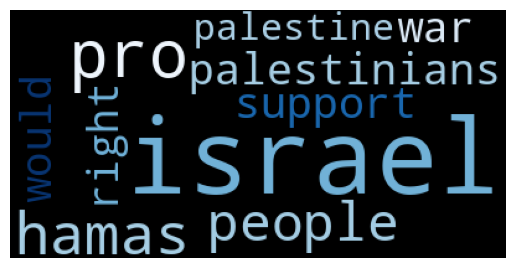

In [ ]:
# Grafice
import matplotlib.pyplot as plt
# WordCloud
from wordcloud import WordCloud
wordcloud_isr = WordCloud(background_color='black',
                      max_words=10,
                      colormap='Blues')
wordcloud_isr.generate_from_frequencies(word_cloud_frecventa_isr)
plt.imshow(wordcloud_isr)
plt.axis('off');

In [ ]:
wordcloud_isr.words_

{'israel': 1.0,
 'pro': 0.25287356321839083,
 'hamas': 0.19157088122605365,
 'people': 0.16091954022988506,
 'palestinians': 0.1532567049808429,
 'support': 0.1532567049808429,
 'would': 0.14559386973180077,
 'right': 0.1417624521072797,
 'war': 0.1417624521072797,
 'palestine': 0.12643678160919541}

In [ ]:
top_words_israel = list(wordcloud_isr.words_)
print(top_words_israel)

['israel', 'pro', 'hamas', 'people', 'palestinians', 'support', 'would', 'right', 'war', 'palestine']


In [ ]:
top_word_freq = {word: word_cloud_frecventa_isr[word] for word in top_words_israel}
print(top_word_freq)

{'israel': 261, 'pro': 66, 'hamas': 50, 'people': 42, 'palestinians': 40, 'support': 40, 'would': 38, 'right': 37, 'war': 37, 'palestine': 33}


In [ ]:
data = {'israel': 261, 'pro': 66, 'hamas': 50, 'people': 42, 'palestinians': 40, 'support': 40, 'would': 38, 'right': 37, 'war': 37, 'palestine': 33, 'think': 29, 'state': 27, 'gaza': 26, 'want': 26, 'also': 24, 'civilian': 24, 'we': 24, 'like': 22, 'country': 18, 'make': 18, 'say': 18, 'attack': 17, 'even': 16, 'jews': 16, 'side': 16, 'terrorist': 16, 'use': 16, 'fight': 15}
df = pd.DataFrame(list(data.items()), columns=['Word', 'Frequency'])
print(df)

            Word  Frequency
0         israel        261
1            pro         66
2          hamas         50
3         people         42
4   palestinians         40
5        support         40
6          would         38
7          right         37
8            war         37
9      palestine         33
10         think         29
11         state         27
12          gaza         26
13          want         26
14          also         24
15      civilian         24
16            we         24
17          like         22
18       country         18
19          make         18
20           say         18
21        attack         17
22          even         16
23          jews         16
24          side         16
25     terrorist         16
26           use         16
27         fight         15


In [ ]:
df.to_csv('my_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('my_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Wordcloud palestine

In [ ]:
dtm_pal = dtm[comments['labelnum']==0].copy()
dtm_pal.shape

(207, 1814)

In [ ]:
word_cloud_frecventa_pal = dtm_pal.sum(axis=0)
word_cloud_frecventa_pal

abhor         1
abhorrent     3
ability       1
able          1
absolute      2
             ..
youth         1
zealot        0
zero          2
zionism       3
zionist      10
Length: 1814, dtype: int64

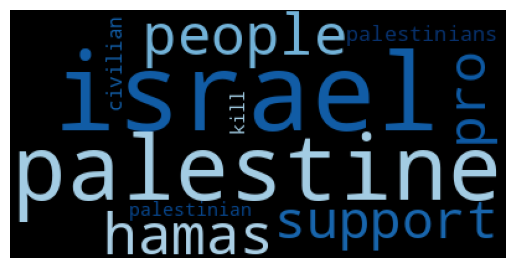

In [ ]:
wordcloud_pal = WordCloud(background_color='black',
                      max_words=10,
                      colormap='Blues')
wordcloud_pal.generate_from_frequencies(word_cloud_frecventa_pal)
plt.imshow(wordcloud_pal)
plt.axis('off');

In [ ]:
wordcloud_pal.words_

{'israel': 1.0,
 'palestine': 0.6940298507462687,
 'people': 0.4253731343283582,
 'hamas': 0.417910447761194,
 'support': 0.3582089552238806,
 'pro': 0.35074626865671643,
 'palestinians': 0.30597014925373134,
 'civilian': 0.26865671641791045,
 'kill': 0.2462686567164179,
 'palestinian': 0.2462686567164179}

In [ ]:
top_words_palestine = list(wordcloud_pal.words_)
print(top_words_palestine)

['israel', 'palestine', 'people', 'hamas', 'support', 'pro', 'palestinians', 'civilian', 'kill', 'palestinian']


In [ ]:
top_word_freq_pal = {word: word_cloud_frecventa_pal[word] for word in top_words_palestine}
print(top_word_freq_pal)

{'israel': 134, 'palestine': 93, 'people': 57, 'hamas': 56, 'support': 48, 'pro': 47, 'palestinians': 41, 'civilian': 36, 'kill': 33, 'palestinian': 33}


In [ ]:
words_palestine = pd.DataFrame(top_word_freq_pal, index=[0])
words_palestine.head(30)

,israel,palestine,people,hamas,support,pro,palestinians,civilian,kill,palestinian
0,134,93,57,56,48,47,41,36,33,33


In [ ]:
words_palestine.to_csv('data.csv', index=False)
files.download('data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Top comentarii Israel

In [21]:
max_score_index = comments['upVotes'].idxmax()

In [22]:
print(max_score_index)

152


In [23]:
max_score_comment = comments.loc[max_score_index, 'text']
max_score_value = comments.loc[max_score_index, 'upVotes']

print("Comment with the highest score:")
print(max_score_comment)
print("Score:", max_score_value)

Comment with the highest score:
I am not for Hamas, I am for Palestine and Palestinians, and I am against Israel not in the sense that the israel people don't deserve dignity and a place to live, but because they are a wealthy, powerful nation with rich allies and they are using a much heavier hand than is necessary to deal with the immediate dangers while contributing to creating the long-term patterns of violence.
Score: 82


In [24]:
comments_sorted = comments.sort_values(by='upVotes', ascending=False)
israel_comments = comments_sorted[comments_sorted['labelnum'] == 1]
top_israel_comments = israel_comments.head(10)
print(top_israel_comments[['text', 'upVotes']])

                                                  text  upVotes
111  I went from moderately supporting Palestine to...       47
75   I'm a huge supporter of Israel, but I would su...       46
389  I'm still for peace for all people, but I'm fo...       38
390  That said, I have been banned from almost ever...       34
0    War is tragic, and this is no exception. That ...       28
398                     I'm not Jewish. I'm pro-Israel       24
352  Israel, obviously. Arabs started a war, lost i...       19
353  Israel for many many many reasons to list some...       17
378  Best i can say I'm pro of the state of Israel ...       16
377  Israel has literally tried everything they cou...       16


In [25]:
top_israel = pd.DataFrame(top_israel_comments[['text', 'upVotes']])
top_israel.head(10)

,text,upVotes
111,I went from moderately supporting Palestine to...,47
75,"I'm a huge supporter of Israel, but I would su...",46
389,"I'm still for peace for all people, but I'm fo...",38
390,"That said, I have been banned from almost ever...",34
0,"War is tragic, and this is no exception. That ...",28
398,I'm not Jewish. I'm pro-Israel,24
352,"Israel, obviously. Arabs started a war, lost i...",19
353,Israel for many many many reasons to list some...,17
378,Best i can say I'm pro of the state of Israel ...,16
377,Israel has literally tried everything they cou...,16


# Top comentarii Palestina

In [26]:
comments_sorted = comments.sort_values(by='upVotes', ascending=False)
palestine_comments = comments_sorted[comments_sorted['labelnum'] == 0]
top_palestine_comments = palestine_comments.head(10)
print(top_palestine_comments[['text', 'upVotes']])

                                                  text  upVotes
152  I am not for Hamas, I am for Palestine and Pal...       82
220  I am pro Palestine because I fully agree with ...       73
153  I'm Irish, and we are a little bit of an early...       68
142  As a historian, I support Palestine because I’...       65
375                                      pro Palestine       47
163  I’m for Palestine and against Israel. Israel i...       41
233  I have becoming more and more pro-Palestinian ...       39
208  It’s not even just that. Israel is starving th...       36
137  On the Palestinian side, I don't support Hamas...       35
213    Innocent people don't deserve to die. Simple as       31


In [28]:
top_palestine = pd.DataFrame(top_palestine_comments[['text', 'upVotes']])
top_palestine.head(10)

,text,upVotes
152,"I am not for Hamas, I am for Palestine and Pal...",82
220,I am pro Palestine because I fully agree with ...,73
153,"I'm Irish, and we are a little bit of an early...",68
142,"As a historian, I support Palestine because I’...",65
375,pro Palestine,47
163,I’m for Palestine and against Israel. Israel i...,41
233,I have becoming more and more pro-Palestinian ...,39
208,It’s not even just that. Israel is starving th...,36
137,"On the Palestinian side, I don't support Hamas...",35
213,Innocent people don't deserve to die. Simple as,31


In [29]:
top_palestine.to_csv('top_palestine_comments.csv', index=False)

In [32]:
from google.colab import files

files.download('top_palestine_comments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Coloana separata cu opinii israel

In [ ]:
israel = comments[comments['labelnum'] == 1]['text']
print(israel)

0      War is tragic, and this is no exception. That ...
1      While Israel waits for their loved ones being ...
5      In all honestly, we can point fingers at Pales...
6                                 I'm firmly pro Israel.
7      I completely support this. I believe that Isra...
                             ...                        
390    That said, I have been banned from almost ever...
391                                      I am pro-Israel
392    As pro-Israel I think it's too much pro-Israel...
398                       I'm not Jewish. I'm pro-Israel
399    honestly I lurk in the Pro Israel subs but rar...
Name: text, Length: 193, dtype: object


In [ ]:
cleaned_israel = comments[comments['labelnum'] == 1]['text_prep']
print(cleaned_israel)

0      war tragic exception say would united states o...
1      israel wait love one hold hostage hamas rest w...
5      honestly point finger palestinians israel end ...
6                                      firmly pro israel
7      completely support believe israel may flawed t...
                             ...                        
390    say ban almost every sub simply try speak reas...
391                                           pro israel
392    pro israel think much pro israel write comment...
398                                    jewish pro israel
399          honestly lurk pro israel sub rarely comment
Name: text_prep, Length: 193, dtype: object


In [ ]:
import numpy as np

# Create a keyword-to-index mapping
keyword_to_index = {keyword: index for index, keyword in enumerate(top_words_israel)}

# Define a function to create the co-occurrence matrix
def create_cooccurrence_matrix(filtered, keyword_to_index):
    cooccurrence_matrix_israel = np.zeros((len(keyword_to_index), len(keyword_to_index)))
    for doc in filtered:
        words = doc.split()
        for i, word in enumerate(words):
            if word in keyword_to_index:
                for j in range(max(0, i-4), min(len(words), i+5)):  # 4-word window
                    if words[j] in keyword_to_index and words[j] != word:
                        cooccurrence_matrix_israel[keyword_to_index[word]][keyword_to_index[words[j]]] += 1
    return cooccurrence_matrix_israel


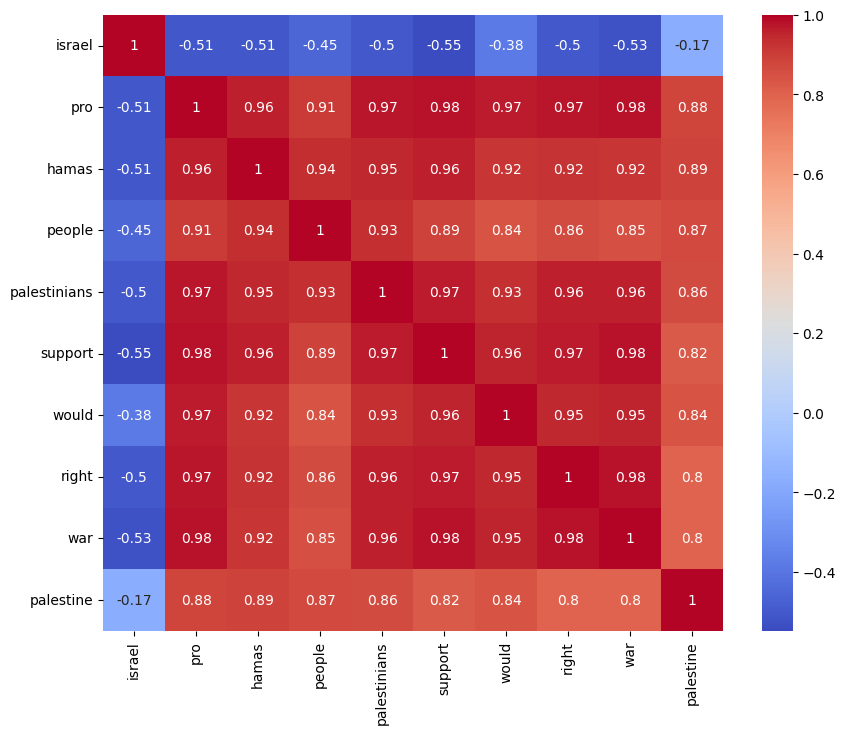

In [ ]:
cooccurrence_matrix_israel = create_cooccurrence_matrix(cleaned_israel, keyword_to_index)
correlation_matrix_israel = pd.DataFrame(cooccurrence_matrix_israel).corr()
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_israel, annot=True, cmap='coolwarm', xticklabels=top_words_israel, yticklabels=top_words_israel)
plt.show()

In [ ]:
cooccurrence_matrix = create_cooccurrence_matrix(cleaned_israel, keyword_to_index)

# Convert to DataFrame for better visualization (optional)
import pandas as pd
cooccurrence_df = pd.DataFrame(cooccurrence_matrix, index=top_words_israel, columns=top_words_israel)
print(cooccurrence_df)

              israel   pro  hamas  people  palestinians  support  would  \
israel           0.0  69.0   23.0    16.0          22.0     30.0   19.0   
pro             69.0   0.0    1.0     1.0           1.0      0.0    4.0   
hamas           23.0   1.0    0.0     3.0           4.0      2.0    2.0   
people          16.0   1.0    3.0     0.0           3.0      5.0    2.0   
palestinians    22.0   1.0    4.0     3.0           0.0      3.0    2.0   
support         30.0   0.0    2.0     5.0           3.0      0.0    1.0   
would           19.0   4.0    2.0     2.0           2.0      1.0    0.0   
right           24.0   2.0    4.0     5.0           3.0      4.0    2.0   
war             19.0   1.0    4.0     3.0           2.0      0.0    2.0   
palestine       16.0   6.0    0.0     0.0           1.0      3.0    5.0   

              right   war  palestine  
israel         24.0  19.0       16.0  
pro             2.0   1.0        6.0  
hamas           4.0   4.0        0.0  
people          5.

In [ ]:
max_size = 3000
min_size = 500
max_freq = max(top_word_freq.values())
min_freq = min(top_word_freq.values())

node_sizes_isr = {word: ((top_word_freq.get(word, 0) - min_freq) / (max_freq - min_freq)) * (max_size - min_size) + min_size for word in G.nodes()}


NameError: name 'G' is not defined

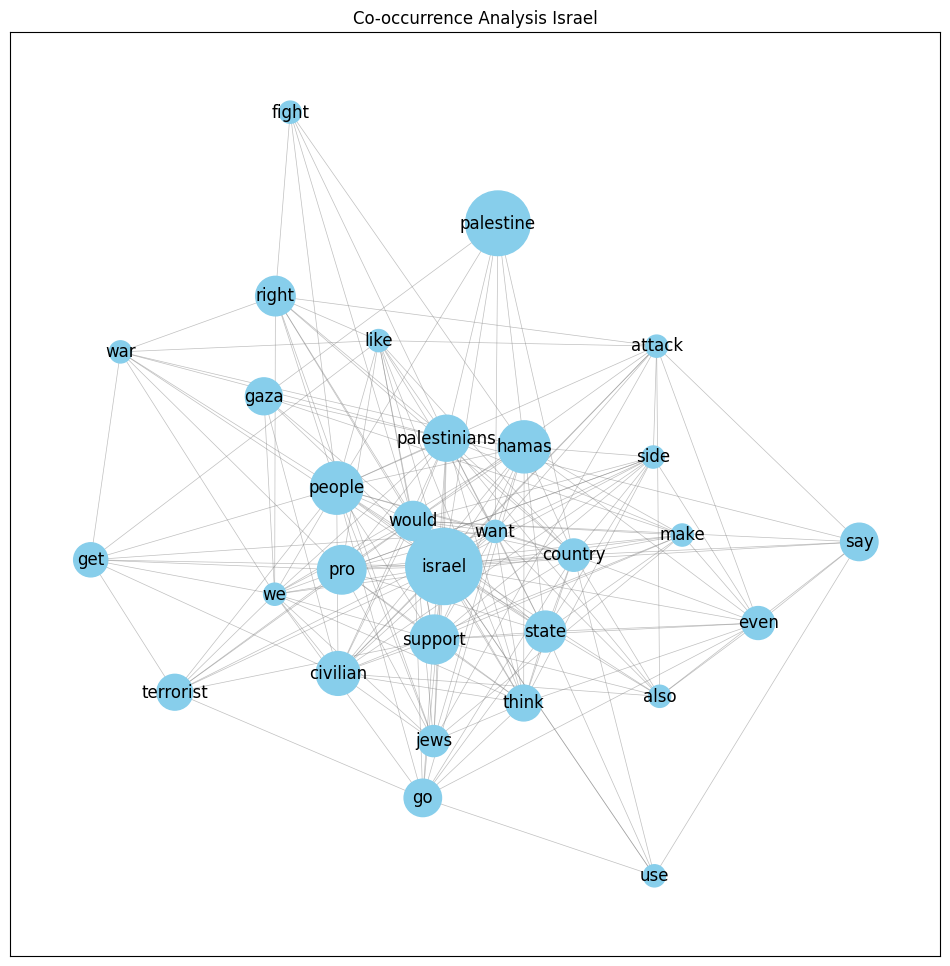

In [ ]:
G = nx.from_numpy_array(cooccurrence_matrix)
G = nx.relabel_nodes(G, dict(enumerate(top_words_israel)))

# Get node sizes in list format
sizes = [node_sizes_isr[node] for node in G.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=12)
plt.title("Co-occurrence Analysis Israel")
plt.show()

# Coloana separata opinii palestina

In [ ]:
palestine = comments[comments['labelnum'] == 1]['text']
print(palestine)

0      War is tragic, and this is no exception. That ...
1      While Israel waits for their loved ones being ...
5      In all honestly, we can point fingers at Pales...
6                                 I'm firmly pro Israel.
7      I completely support this. I believe that Isra...
                             ...                        
390    That said, I have been banned from almost ever...
391                                      I am pro-Israel
392    As pro-Israel I think it's too much pro-Israel...
398                       I'm not Jewish. I'm pro-Israel
399    honestly I lurk in the Pro Israel subs but rar...
Name: text, Length: 193, dtype: object


In [ ]:
cleaned_palestine = comments[comments['labelnum'] == 1]['text_prep']
print(cleaned_palestine)

0      war tragic exception say would united states o...
1      israel wait love one hold hostage hamas rest w...
5      honestly point finger palestinians israel end ...
6                                      firmly pro israel
7      completely support believe israel may flawed t...
                             ...                        
390    say ban almost every sub simply try speak reas...
391                                           pro israel
392    pro israel think much pro israel write comment...
398                                    jewish pro israel
399          honestly lurk pro israel sub rarely comment
Name: text_prep, Length: 193, dtype: object


In [ ]:
import numpy as np

# Create a keyword-to-index mapping
keyword_to_index = {keyword: index for index, keyword in enumerate(top_words_palestine)}

# Define a function to create the co-occurrence matrix
def create_cooccurrence_matrix(palestine, keyword_to_index):
    cooccurrence_matrix = np.zeros((len(keyword_to_index), len(keyword_to_index)))
    for doc in palestine:
        words = doc.split()
        for i, word in enumerate(words):
            if word in keyword_to_index:
                for j in range(max(0, i-4), min(len(words), i+5)):  # 4-word window
                    if words[j] in keyword_to_index and words[j] != word:
                        cooccurrence_matrix[keyword_to_index[word]][keyword_to_index[words[j]]] += 1
    return cooccurrence_matrix

In [ ]:
cooccurrence_matrix = create_cooccurrence_matrix(cleaned_palestine, keyword_to_index)
correlation_matrix = pd.DataFrame(cooccurrence_matrix).corr()

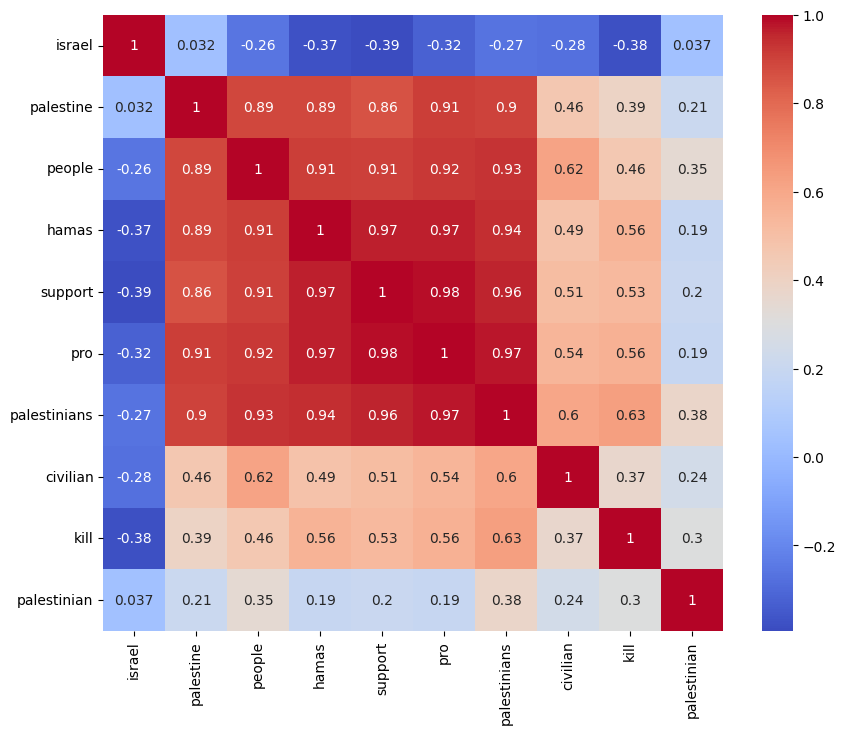

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=top_words_palestine, yticklabels=top_words_palestine)
plt.show()

In [ ]:
cooccurrence_matrix = create_cooccurrence_matrix(cleaned_palestine, keyword_to_index)

# Convert to DataFrame for better visualization (optional)
import pandas as pd
cooccurrence_df = pd.DataFrame(cooccurrence_matrix, index=top_words_palestine, columns=top_words_palestine)
print(cooccurrence_df)

              israel  palestine  people  hamas  support   pro  palestinians  \
israel           0.0       16.0    16.0   23.0     30.0  69.0          22.0   
palestine       16.0        0.0     0.0    0.0      3.0   6.0           1.0   
people          16.0        0.0     0.0    3.0      5.0   1.0           3.0   
hamas           23.0        0.0     3.0    0.0      2.0   1.0           4.0   
support         30.0        3.0     5.0    2.0      0.0   0.0           3.0   
pro             69.0        6.0     1.0    1.0      0.0   0.0           1.0   
palestinians    22.0        1.0     3.0    4.0      3.0   1.0           0.0   
civilian         4.0        0.0     0.0    4.0      1.0   0.0           1.0   
kill             3.0        1.0     1.0    2.0      1.0   0.0           0.0   
palestinian      2.0        0.0     3.0    2.0      4.0   0.0           0.0   
state           11.0        1.0     2.0    0.0      1.0   1.0           4.0   
right           24.0        4.0     5.0    4.0      

In [ ]:
max_size = 3000
min_size = 500
max_freq = max(top_word_freq_pal.values())
min_freq = min(top_word_freq_pal.values())

node_sizes = {word: ((top_word_freq[word] - min_freq) / (max_freq - min_freq)) * (max_size - min_size) + min_size for word in top_words_palestine}

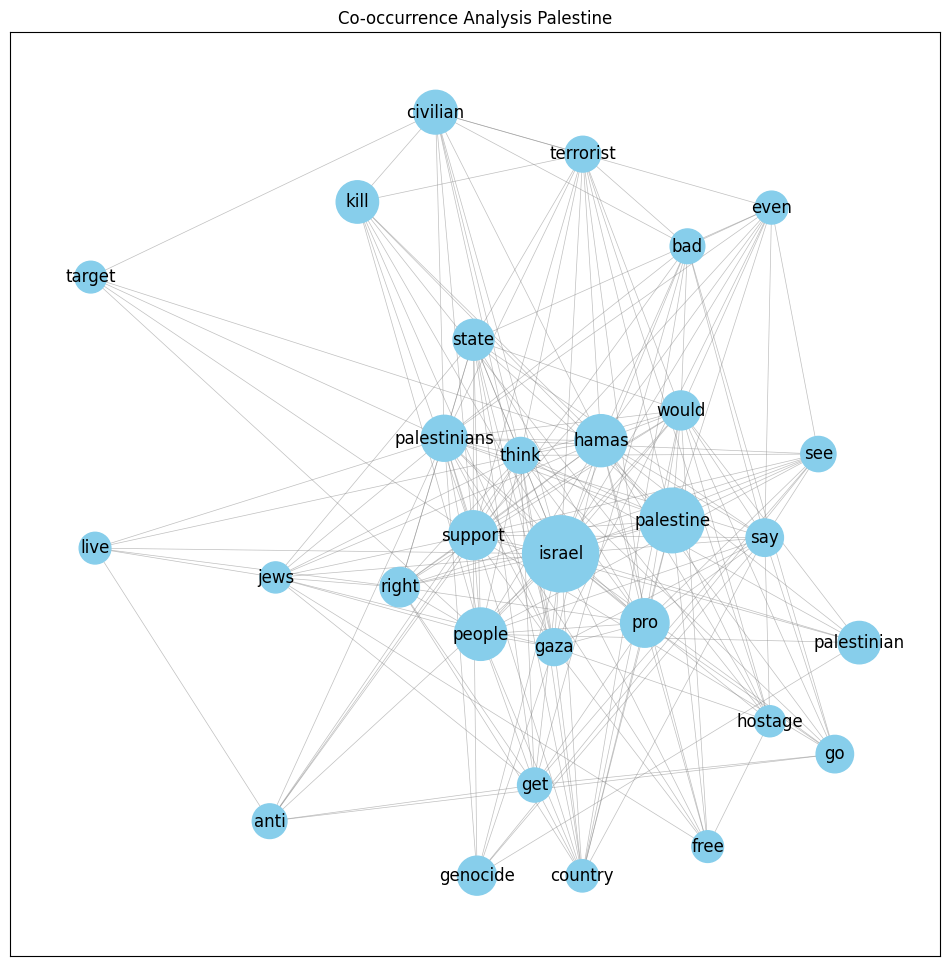

In [ ]:
import networkx as nx
# Build the co-occurrence network
G = nx.from_numpy_array(cooccurrence_matrix)
G = nx.relabel_nodes(G, dict(enumerate(top_words_palestine)))

sizes = [node_sizes[node] for node in G.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=12)
plt.title("Co-occurrence Analysis Palestine")
plt.show()